In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
np.random.seed(42)

In [2]:
n1, n2, n3 = 200, 200, 200
data1 = np.random.normal(loc=-5, scale=1.0, size=n1)
data2 = np.random.normal(loc=0, scale=0.8, size=n2)
data3 = np.random.normal(loc=4, scale=1.2, size=n3)
X = np.concatenate([data1, data2, data3])
X = X.reshape(-1, 1)
print("Total number of samples:", len(X))

Total number of samples: 600


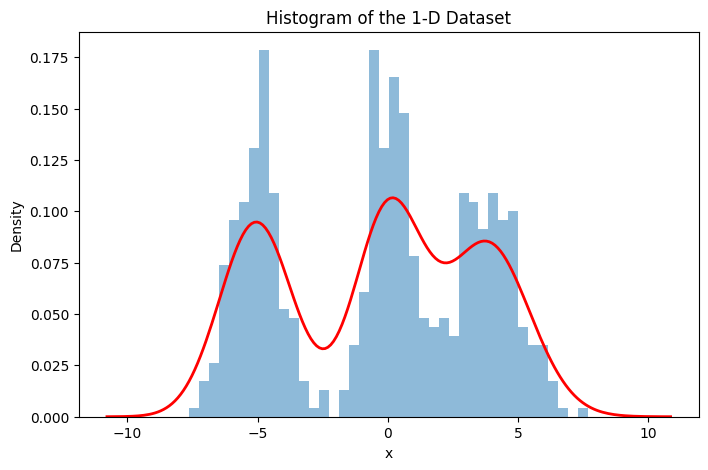

In [7]:
plt.figure(figsize=(8,5))
plt.hist(X, bins=40, density=True, alpha=0.5, label="Histogram")
sns.kdeplot(X.flatten(), color="red", linewidth=2, label="Density curve")
plt.title("Histogram of the 1-D Dataset")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

In [8]:
def gaussian_pdf(x, mean, variance):
    coefficient = 1 / np.sqrt(2 * np.pi * variance)
    exponent = np.exp(-((x - mean) ** 2) / (2 * variance))
    return coefficient * exponent

In [9]:
# number of mixtures
K = 3


# initialize means by randomly choosing data points
means = np.random.choice(X.flatten(), K)

# initialize variances
variances = np.full(K, np.var(X))

# initialize mixing coefficients equally
weights = np.full(K, 1 / K)

print("Initial means:", means)
print("Initial variances:", variances)
print("Initial weights:", weights)

Initial means: [-5.34271452  4.08891374  1.15301863]
Initial variances: [14.37194178 14.37194178 14.37194178]
Initial weights: [0.33333333 0.33333333 0.33333333]


In [10]:
def expectation_step(X, means, variances, weights):
    
    n = len(X)
    K = len(means)
    
    # responsibility matrix - for each datapoint xi , what is the probability that it was generated by gaussian component k
    responsibilities = np.zeros((n, K))
    
    for k in range(K):
        responsibilities[:, k] = weights[k] * gaussian_pdf(X.flatten(), means[k], variances[k])
    
    # normalize rows so they sum to 1
    row_sums = responsibilities.sum(axis=1, keepdims=True)
    responsibilities = responsibilities / row_sums
    
    return responsibilities

In [11]:
def maximization_step(X, responsibilities):
    
    n, K = responsibilities.shape
    
    Nk = responsibilities.sum(axis=0)
    
    # update weights
    weights = Nk / n
    
    # update means
    means = (responsibilities.T @ X.flatten()) / Nk
    
    # update variances
    variances = np.zeros(K)
    
    for k in range(K):
        diff = X.flatten() - means[k]
        variances[k] = np.sum(responsibilities[:, k] * diff**2) / Nk[k]
    
    return means, variances, weights

In [12]:
def compute_log_likelihood(X, means, variances, weights):
    
    n = len(X)
    K = len(means)
    
    likelihood = np.zeros((n, K))
    
    for k in range(K):
        likelihood[:, k] = weights[k] * gaussian_pdf(X.flatten(), means[k], variances[k])
    
    total_likelihood = np.sum(likelihood, axis=1)
    
    log_likelihood = np.sum(np.log(total_likelihood))
    
    return log_likelihood

In [17]:
means_history = []
variances_history = []
weights_history = []

max_iters = 50
tolerance = 1e-6

log_likelihoods = []

for iteration in range(max_iters):

    # store current parameters
    means_history.append(means.copy())
    variances_history.append(variances.copy())
    weights_history.append(weights.copy())

    # E-step
    responsibilities = expectation_step(X, means, variances, weights)

    # M-step
    means, variances, weights = maximization_step(X, responsibilities)

    # log likelihood
    ll = compute_log_likelihood(X, means, variances, weights)
    log_likelihoods.append(ll)

    if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tolerance:
        print("Converged")
        break

Converged


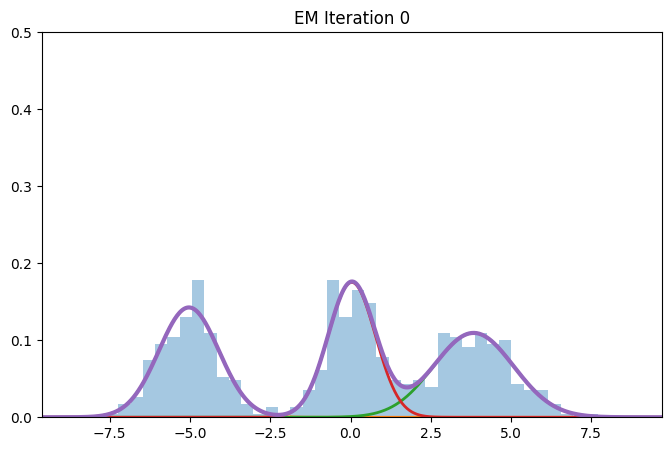

In [21]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

x_vals = np.linspace(X.min() - 2, X.max() + 2, 500)

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(X, bins=40, density=True, alpha=0.4)

lines = []
for k in range(K):
    line, = ax.plot([], [], lw=2)
    lines.append(line)

mixture_line, = ax.plot([], [], lw=3)

ax.set_xlim(x_vals.min(), x_vals.max())
ax.set_ylim(0, 0.5)

def update(frame):

    means = means_history[frame]
    variances = variances_history[frame]
    weights = weights_history[frame]

    mixture_curve = np.zeros_like(x_vals)

    for k in range(K):

        gaussian = weights[k] * gaussian_pdf(x_vals, means[k], variances[k])
        mixture_curve += gaussian

        lines[k].set_data(x_vals, gaussian)

    mixture_line.set_data(x_vals, mixture_curve)

    ax.set_title(f"EM Iteration {frame}")

    return lines + [mixture_line]


anim = FuncAnimation(fig, update, frames=len(means_history), interval=400)

HTML(anim.to_jshtml())

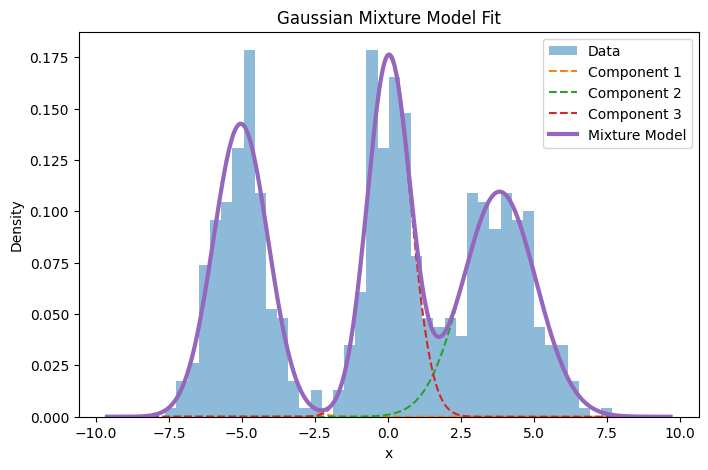

In [14]:
x_vals = np.linspace(X.min() - 2, X.max() + 2, 500)

plt.figure(figsize=(8,5))

# histogram
plt.hist(X, bins=40, density=True, alpha=0.5, label="Data")

mixture_curve = np.zeros_like(x_vals)

# plot each component
for k in range(K):
    
    gaussian = weights[k] * gaussian_pdf(x_vals, means[k], variances[k])
    
    mixture_curve += gaussian
    
    plt.plot(x_vals, gaussian, linestyle="--", label=f"Component {k+1}")

# plot full mixture
plt.plot(x_vals, mixture_curve, linewidth=3, label="Mixture Model")

plt.title("Gaussian Mixture Model Fit")
plt.xlabel("x")
plt.ylabel("Density")

plt.legend()
plt.show()

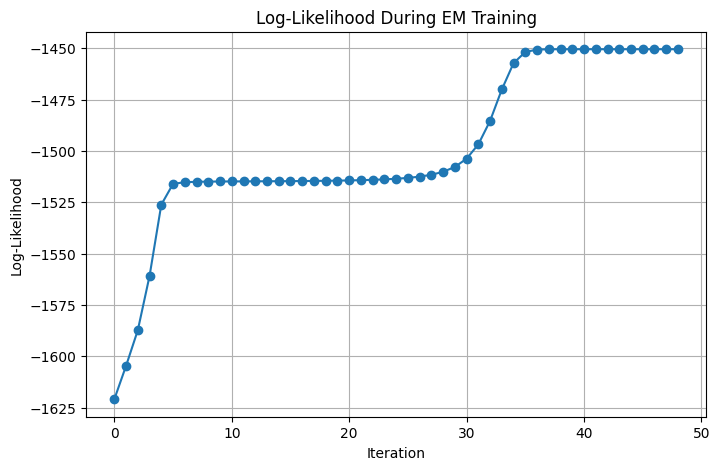

In [15]:
plt.figure(figsize=(8,5))

plt.plot(log_likelihoods, marker='o')

plt.title("Log-Likelihood During EM Training")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")

plt.grid(True)

plt.show()